محمد حسن مسافری     
شماره دانشجویی:4042013200

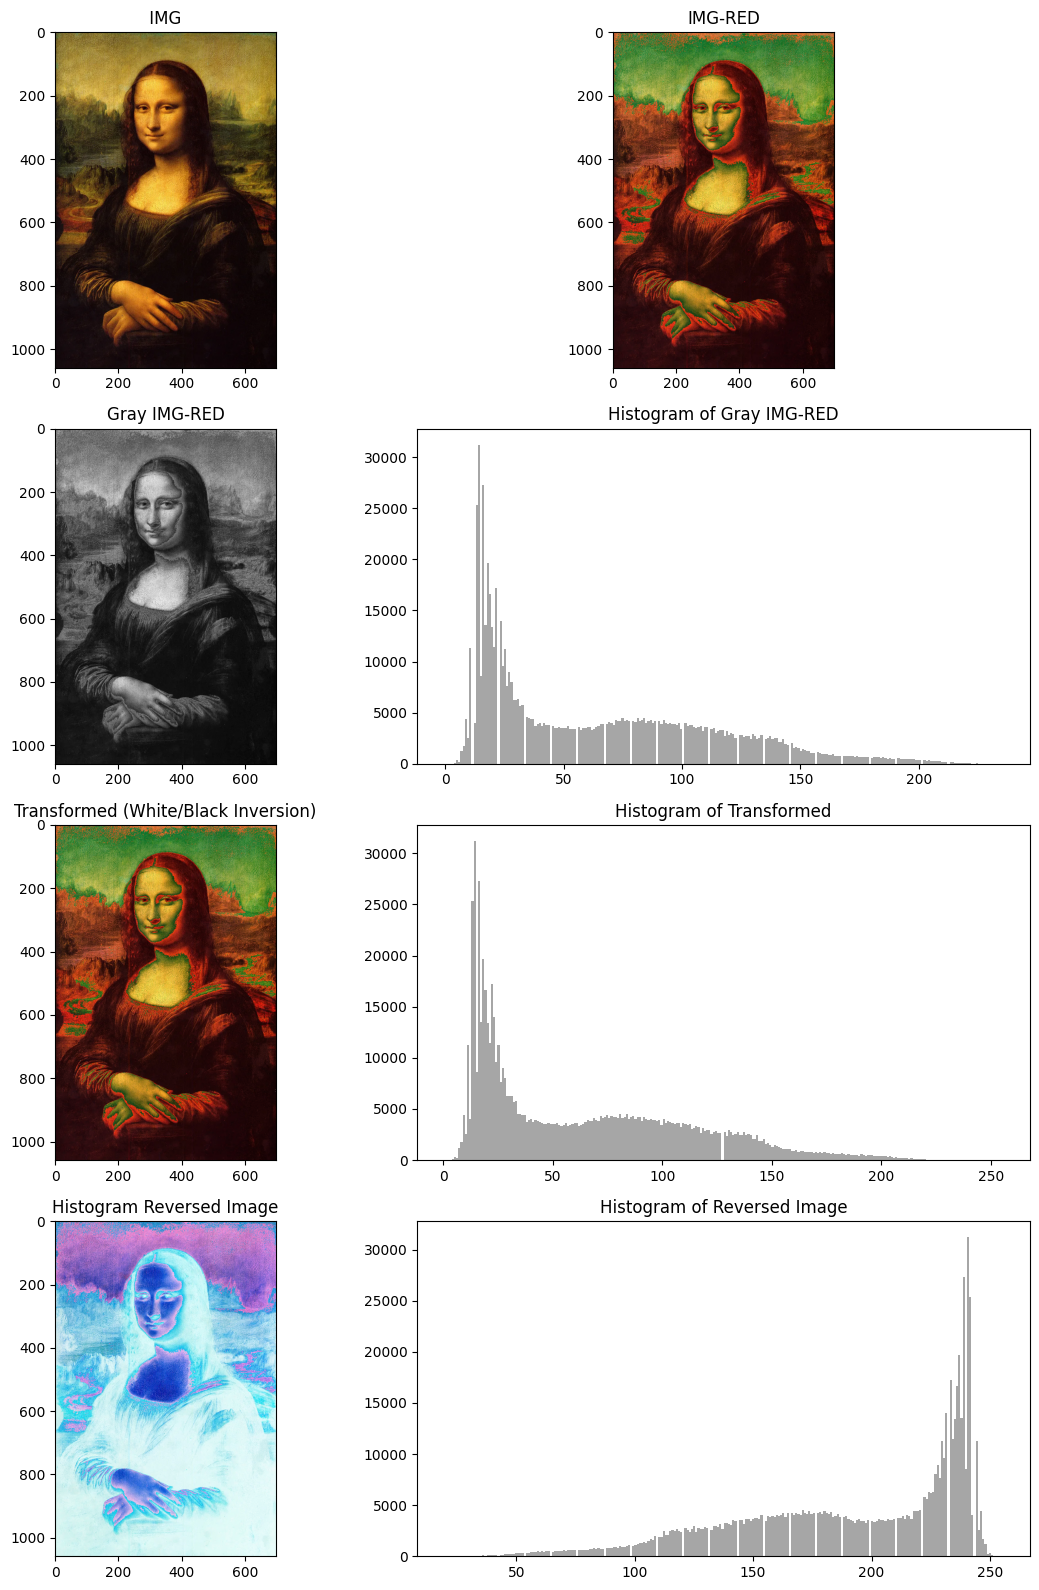

محمدحسن مسافری
شماره دانشجویی:4042013200


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class ImageProcessor:
    def __init__(self, image_path):
        self.img = cv2.imread(image_path)
        if self.img is None:
            raise FileNotFoundError(f"Error: Could not load image at {image_path}. Check the path.")
        self.img = cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB)

    def plot_histogram(self, image, ax, title):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        ax.hist(gray.ravel(), bins=256, color='gray', alpha=0.7)
        ax.set_title(title)

    def process_and_show(self):
        # 1. IMG (Original)
        img = self.img
        
        # 2. IMG-RED (Red channel * 2)
        img_red = img.copy()
        img_red[:, :, 0] = np.clip(img_red[:, :, 0] * 2, 0, 255)
        
        # 3.(White <-> Black)تغیر کردن 
        transformed = img_red.copy()
        white_mask = np.all(img_red == [255, 255, 255], axis=-1)
        black_mask = np.all(img_red == [0, 0, 0], axis=-1)
        transformed[white_mask] = [0, 0, 0]
        transformed[black_mask] = [255, 255, 255]
        
        # 4. هیستوگرام معکوس (حدود ۱۲۸)
        hist_reversed = 255 - img_red

        # تنظیم زیرطرح (4، 2)
        fig, axes = plt.subplots(4, 2, figsize=(12, 16))
        
        # 1,1 : IMG | 1,2 : IMG-RED
        axes[0, 0].imshow(img)
        axes[0, 0].set_title(" IMG ")
        axes[0, 1].imshow(img_red)
        axes[0, 1].set_title("IMG-RED")
        
        # 2,1 : Gray IMG-RED | 2,2 :  IMG-RED هیستوگرام خاکستری 
        gray_red = cv2.cvtColor(img_red, cv2.COLOR_RGB2GRAY)
        axes[1, 0].imshow(gray_red, cmap='gray')
        axes[1, 0].set_title("Gray IMG-RED")
        self.plot_histogram(img_red, axes[1, 1], "Histogram of Gray IMG-RED")
        
        # 3,1 : Transformed | 3,2 : Histogram of Transformed
        axes[2, 0].imshow(transformed)
        axes[2, 0].set_title("Transformed (White/Black Inversion)")
        self.plot_histogram(transformed, axes[2, 1], "Histogram of Transformed")
        
        # 4,1 : Reversed Hist Image | 4,2 : Histogram of Reversed
        axes[3, 0].imshow(hist_reversed)
        axes[3, 0].set_title("Histogram Reversed Image")
        self.plot_histogram(hist_reversed, axes[3, 1], "Histogram of Reversed Image")
        
        plt.tight_layout()
        plt.show()


# اجرای برنامه
if __name__ == "__main__":
    try:
        processor = ImageProcessor(r"C:/Users/user/Desktop/mona.webp")
        processor.process_and_show()
    except Exception as e:
        print(e)
        
        
        
print("محمدحسن مسافری\nشماره دانشجویی:4042013200")